# Project 6: Feature Engineering

## Objective

Prepare the IBM Telco Customer Churn dataset for machine learning by creating new features, encoding categorical variables, scaling numerical features, and selecting the final feature set.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.replace(" ", np.nan, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.shape

(7043, 21)

In [7]:
df["AverageMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

In [8]:
df["Loyalty"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=["New","Regular","Loyal","Very Loyal"]
)

In [9]:
df[["tenure","AverageMonthlySpend","Loyalty"]].head()

,tenure,AverageMonthlySpend,Loyalty
0,1,14.925000,New
1,34,53.985714,Loyal
2,2,36.050000,New
3,45,40.016304,Loyal
4,2,50.550000,New


In [10]:
df["SeniorCitizen"] = df["SeniorCitizen"].replace(
    {
        0:"No",
        1:"Yes"
    }
)

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,Loyalty
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,New
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,Loyal
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,New
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,Loyal
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,New


In [12]:
df.select_dtypes(include="object").columns

/var/folders/7z/j70yd5z95_3_6ygy1dzk72mr0000gn/T/ipykernel_5235/1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Churn'],
      dtype='str')

In [13]:
le = LabelEncoder()

df["Churn"] = le.fit_transform(df["Churn"])

In [14]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [15]:
# Remove unique identifier
df = df.drop(columns=["customerID"])

# One-Hot Encode only categorical columns
categorical_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

/var/folders/7z/j70yd5z95_3_6ygy1dzk72mr0000gn/T/ipykernel_5235/2483204972.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [16]:
df.shape

(7043, 33)

In [17]:
df.columns.tolist()

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'AverageMonthlySpend',
 'Loyalty',
 'gender_Male',
 'SeniorCitizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [18]:
df.head()

,tenure,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,Loyalty,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,14.925000,New,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,0,53.985714,Loyal,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,1,36.050000,New,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,0,40.016304,Loyal,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,2,70.70,151.65,1,50.550000,New,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [19]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AverageMonthlySpend"
]

In [20]:
scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [21]:
df[numerical_columns].describe()

,tenure,MonthlyCharges,TotalCharges,AverageMonthlySpend
count,7.043000e+03,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-1.488074e-17,6.053182e-18
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-9.991203e-01,-8.520814e-01
25%,-9.516817e-01,-9.725399e-01,-8.298459e-01,-5.719705e-01
50%,-1.372744e-01,1.857327e-01,-3.904632e-01,-3.837251e-04
75%,9.214551e-01,8.338335e-01,6.642871e-01,3.895187e-01
max,1.613701e+00,1.794352e+00,2.826743e+00,2.190106e+01


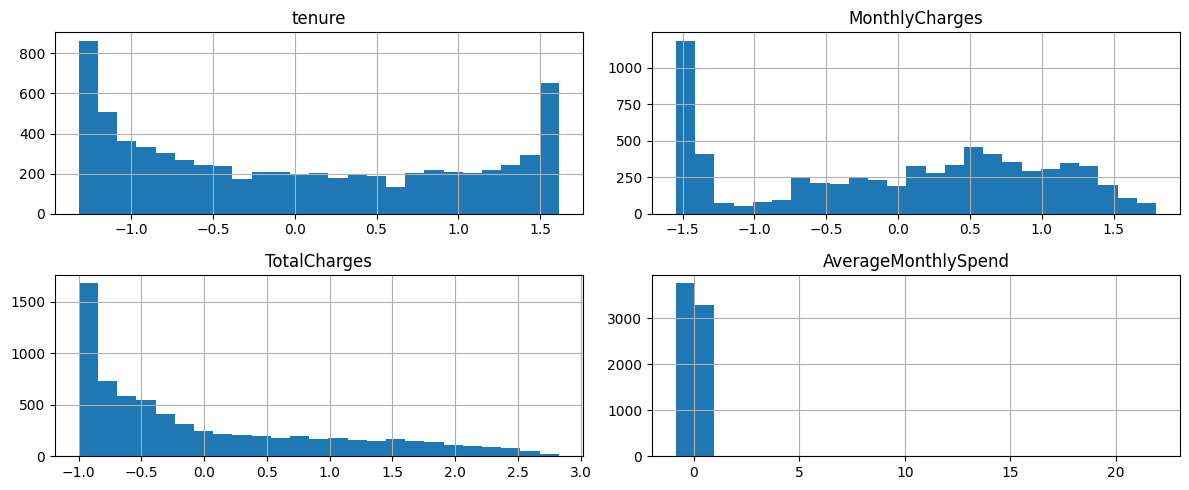

In [22]:
df[numerical_columns].hist(
    figsize=(12,5),
    bins=25
)

plt.tight_layout()

plt.show()

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   tenure                                 7043 non-null   float64 
 1   MonthlyCharges                         7043 non-null   float64 
 2   TotalCharges                           7043 non-null   float64 
 3   Churn                                  7043 non-null   int64   
 4   AverageMonthlySpend                    7043 non-null   float64 
 5   Loyalty                                7032 non-null   category
 6   gender_Male                            7043 non-null   int64   
 7   SeniorCitizen_Yes                      7043 non-null   int64   
 8   Partner_Yes                            7043 non-null   int64   
 9   Dependents_Yes                         7043 non-null   int64   
 10  PhoneService_Yes                       7043 non-null   int64   
 11  Mu

In [24]:
correlation = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

correlation

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen_Yes                        0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
AverageMonthlySpend                      0.014873
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674


In [25]:
correlation.head(15)

Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen_Yes                 0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
AverageMonthlySpend               0.014873
PhoneService_Yes                  0.011942
gender_Male                      -0.008612
MultipleLines_No phone service   -0.011942
DeviceProtection_Yes             -0.066160
OnlineBackup_Yes                 -0.082255
Name: Churn, dtype: float64

In [26]:
correlation.tail(15)

Partner_Yes                            -0.150448
Dependents_Yes                         -0.164221
TechSupport_Yes                        -0.164674
OnlineSecurity_Yes                     -0.171226
Contract_One year                      -0.177820
TotalCharges                           -0.199037
StreamingMovies_No internet service    -0.227890
OnlineBackup_No internet service       -0.227890
StreamingTV_No internet service        -0.227890
TechSupport_No internet service        -0.227890
DeviceProtection_No internet service   -0.227890
OnlineSecurity_No internet service     -0.227890
InternetService_No                     -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
Name: Churn, dtype: float64

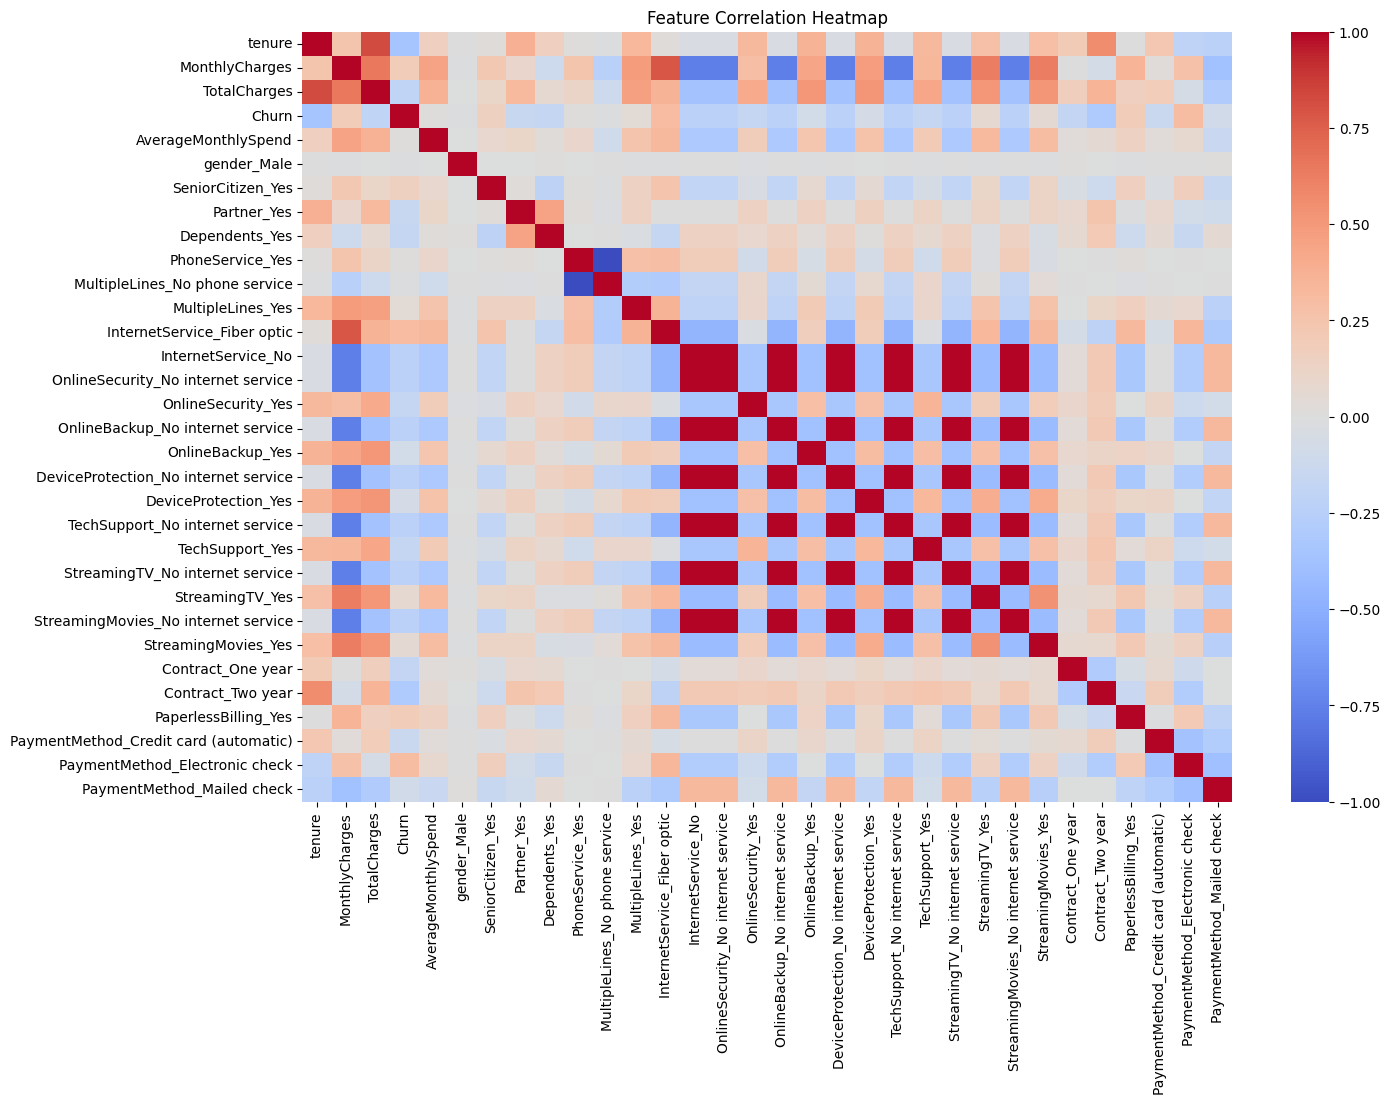

In [27]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [28]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [29]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (7043, 32)
Target Shape   : (7043,)


In [30]:
list(X.columns)

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'AverageMonthlySpend',
 'Loyalty',
 'gender_Male',
 'SeniorCitizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [31]:
df.to_csv(
    "../outputs/telco_feature_engineered.csv",
    index=False
)

In [32]:
X.to_csv(
    "../outputs/X_features.csv",
    index=False
)

y.to_csv(
    "../outputs/y_target.csv",
    index=False
)

# Feature Engineering Summary

### New Features Created

- AverageMonthlySpend
- Loyalty Category

### Transformations Applied

- Missing value handling
- Data type conversion
- Label Encoding
- One-Hot Encoding
- Standard Scaling

### Outputs Generated

- Engineered dataset
- Feature matrix (X)
- Target variable (y)

The dataset is now ready for machine learning model development.

In [33]:
print("="*60)
print("PROJECT 6 : FEATURE ENGINEERING")
print("="*60)

print(f"Rows               : {df.shape[0]}")
print(f"Columns            : {df.shape[1]}")
print(f"Features           : {X.shape[1]}")
print(f"Target Variable    : {y.name}")

print("\nFeature Engineering Completed Successfully!")

PROJECT 6 : FEATURE ENGINEERING
Rows               : 7043
Columns            : 33
Features           : 32
Target Variable    : Churn

Feature Engineering Completed Successfully!
